In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns


In [3]:
import csv

def histogram_multiple(file, skip, teff_ranges, rad_min, rad_max, period_min, period_max):
    plt.figure(figsize=(10, 6))

    df = pd.read_csv(file, skiprows=skip)

    if 'Stellar Eff Temp (K)' in df.columns:
        df.rename(columns={'Stellar Eff Temp (K)': 'st_teff'}, inplace=True)
    if 'Planet Radius (R_Earth)' in df.columns:
        df.rename(columns={'Planet Radius (R_Earth)': 'pl_rade'}, inplace=True)

    df = df.dropna(subset=['st_teff', 'pl_rade'])
    df = df[(df['pl_rade'] < rad_max) & (df['pl_rade'] > rad_min)]
    df = df[(df['pl_orbper'] < period_max) & (df['pl_orbper'] > period_min)]

    if 'tfopwg_disp' in df.columns:
        df = df[df['tfopwg_disp'] != 'FP']

    for teff_min, teff_max in teff_ranges:
        df_filtered = df[(df['st_teff'] < teff_max) & (df['st_teff'] > teff_min)]

        x_err = df_filtered['pl_radeerr1'].values
        perturbed_rade = df_filtered['pl_rade'] + np.random.uniform(-1, 1, size=len(df_filtered)) * df_filtered['pl_radeerr1']
        df_filtered['pl_perturbed'] = perturbed_rade
        
        # Perturb df_filtered['pl_rade'] for each row individually within x_err

        # Plot the original data with error bars
        #plt.errorbar(df_filtered['pl_rade'], df_filtered['st_teff'], xerr=x_err, alpha=0.5, label=f'{teff_min}-{teff_max}K')
        plt.scatter(df_filtered['pl_rade'], df_filtered['st_teff'], alpha=0.5, label=f'{teff_min}-{teff_max}K')

        # Plot the perturbed data
        #plt.scatter(df_filtered['perturbed_rade'], df_filtered['st_teff'], alpha=0.5, label=f'Perturbed {teff_min}-{teff_max}K', marker='x')
        if 'pl_name' in df_filtered.columns:
            for i, txt in enumerate(df_filtered['pl_name']):
                plt.annotate(txt, (df_filtered['pl_rade'].iloc[i], df_filtered['st_teff'].iloc[i]), fontsize=8, alpha=0.7)

        #save for control group
        #df_filtered.to_csv('TOI_Mar2025_1pt5to4_R.csv', index=False)




    plt.title('Planetary Radius vs Stellar Effective Temperature')
    plt.ylabel('Stellar Effective Temperature (K)')
    plt.xlabel('Planetary Radius (Earth Radii)')
    plt.grid(True)


    plt.plot(rp_earth_values, teff_values,marker='o', label = "Minimum Detectable Radius scaled")
    plt.legend()

    plt.show()
    plt.figure(figsize=(10, 6))
    mean_median_data = []

    for teff_min, teff_max in teff_ranges:
        df_filtered = df[(df['st_teff'] < teff_max) & (df['st_teff'] > teff_min)]

        perturbed_rade = df_filtered['pl_rade'] + np.random.uniform(-1, 1, size=len(df_filtered)) * df_filtered['pl_radeerr1']
        df_filtered['pl_perturbed'] = perturbed_rade


        plt.hist(df_filtered['pl_rade'], alpha=0.5, label=f'{teff_min}-{teff_max}K')
        print(len(df_filtered['pl_rade']))
        #PERTURBED
        #plt.hist(df_filtered['pl_perturbed'], alpha=0.5, label=f'{teff_min}-{teff_max}K')




        #print(df_filtered['st_rad'].mean())#, df_filtered['st_rad'].median())

        # Calculate mean and median
        mean = df_filtered['pl_rade'].mean()
        median = df_filtered['pl_rade'].median()
        #PERTURBED
        # mean = df_filtered['pl_perturbed'].mean()
        # median = df_filtered['pl_perturbed'].median()

        # Save mean and median to the list
        mean_median_data.append({'Teff Range': f'{teff_min}-{teff_max}K', 'Mean': mean, 'Median': median})

        # Plot median line
        color = plt.gca().patches[-1].get_facecolor()  # Get the color of the last histogram bar
        plt.axvline(median, linestyle='dashed', linewidth=2, color=color, label=f'median, {teff_min}-{teff_max}K')
        plt.text(median, plt.ylim()[1] * 0.8, f'{median:.2f}', fontsize=8, rotation=90, verticalalignment='center')



    # Save the mean and median data to a CSV file
    # with open('mean_median_data.csv', mode='w', newline='') as file:
    #     writer = csv.DictWriter(file, fieldnames=['Teff Range', 'Mean', 'Median'])
    #     writer.writeheader()
    #     writer.writerows(mean_median_data)

    plt.xlabel('Planetary Radius (Earth Radii)')
    plt.ylabel('Frequency')
    plt.title('Histogram of Planetary Radius')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
    plt.grid(True)
    plt.show()

    # Cumulative distribution lines
    fig, ax1 = plt.subplots(figsize=(10, 6))
    for teff_min, teff_max in teff_ranges:
        df_filtered = df[(df['st_teff'] < teff_max) & (df['st_teff'] > teff_min)]
        ax1.hist(df_filtered['pl_rade'], bins=len(df_filtered['pl_rade'])*3, alpha=0.5, label=f'{teff_min}-{teff_max}K', cumulative=True, histtype='step', density=True)

    ax1.set_xlabel('Planetary Radius (Earth Radii)')
    ax1.set_ylabel('Cumulative Frequency')
    ax1.set_title('Cumulative Distribution of Planetary Radius')
    ax1.legend()
    ax1.grid(True)



    plt.show()


/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_80977/1612485652.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['pl_perturbed'] = perturbed_rade
/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_80977/1612485652.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['pl_perturbed'] = perturbed_rade
/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_80977/1612485652.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

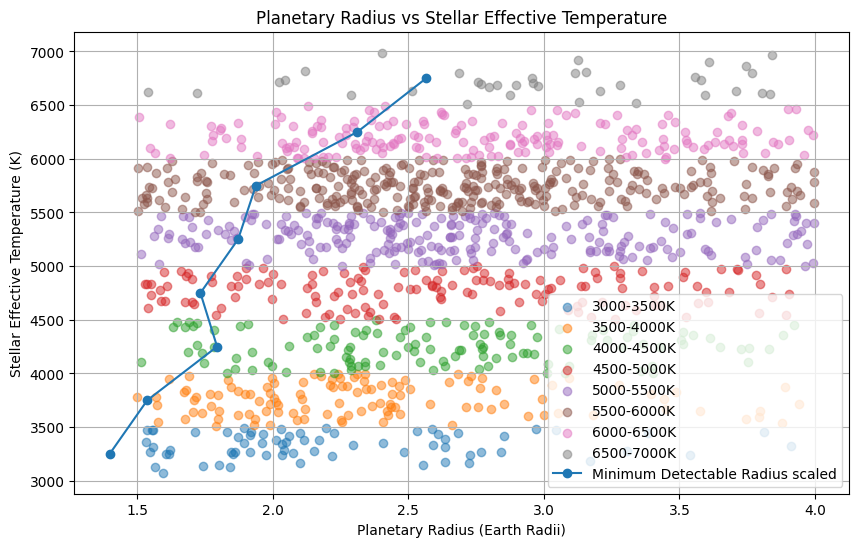

/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_80977/1612485652.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['pl_perturbed'] = perturbed_rade
/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_80977/1612485652.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['pl_perturbed'] = perturbed_rade
/var/folders/m_/l_xwjgkd4dn3xl_27hw7d3sh0000gn/T/ipykernel_80977/1612485652.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

69
118
120
145
225
300
176
36


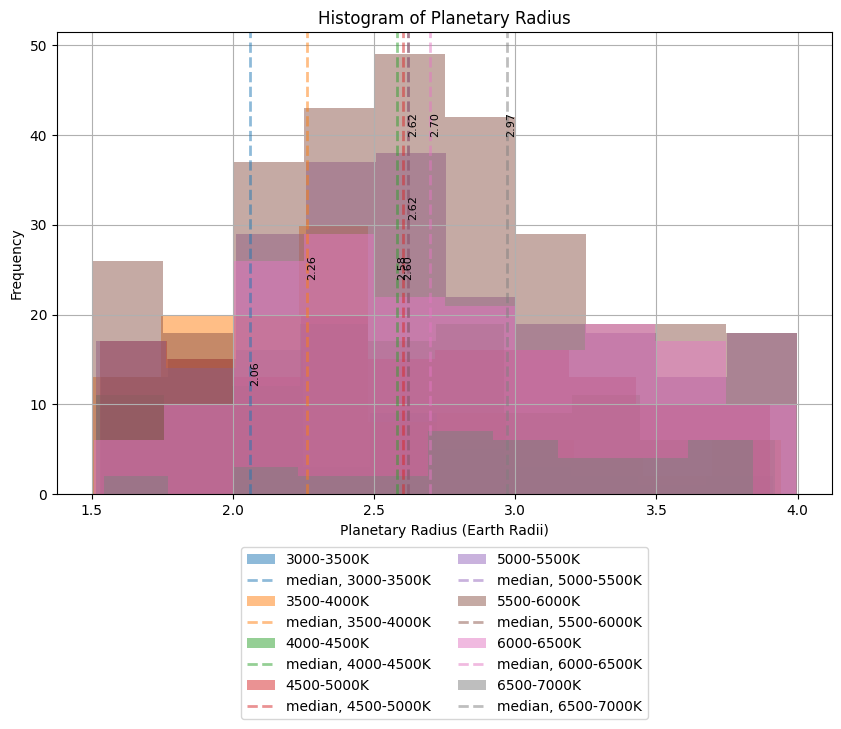

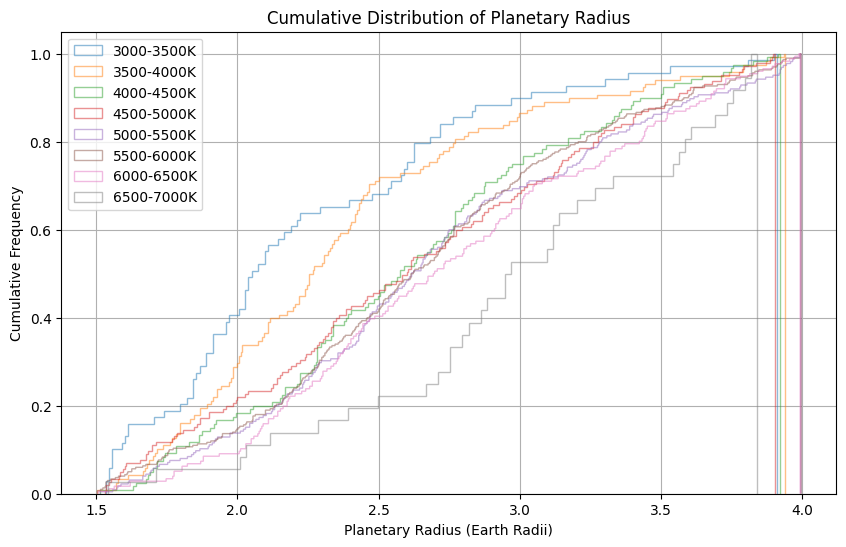

In [10]:
teff_ranges = [(3000, 3500), (3500, 4000), (4000, 4500), (4500, 5000), (5000, 5500), (5500, 6000), (6000, 6500), (6500, 7000)]#, (7000,8000)]
rad_min = 1.5
rad_max = 4
period_min = 0
period_max = 100000

histogram_multiple('TOI_Mar2025.csv', 0, teff_ranges, rad_min, rad_max, period_min, period_max)

#! Plot KDEs of hists

In [ ]:
def histogram_KDE(file, skip, teff_ranges, rad_min, rad_max):
    df_combined = pd.DataFrame()
    plt.figure(figsize=(10, 6))

    df = pd.read_csv(file, skiprows=skip)

    if 'Stellar Eff Temp (K)' in df.columns:
        df.rename(columns={'Stellar Eff Temp (K)': 'st_teff'}, inplace=True)
    if 'Planet Radius (R_Earth)' in df.columns:
        df.rename(columns={'Planet Radius (R_Earth)': 'pl_rade'}, inplace=True)

    df = df.dropna(subset=['st_teff', 'pl_rade'])
    df = df[(df['pl_rade'] < rad_max) & (df['pl_rade'] > rad_min)]

    if 'tfopwg_disp' in df.columns:
        df = df[df['tfopwg_disp'] != 'FP']

  
    mean_median_data = []

    # for teff_min, teff_max in teff_ranges:
    #     df_filtered = df[(df['st_teff'] < teff_max) & (df['st_teff'] > teff_min)]
    #     plt.hist(df_filtered['pl_rade'], alpha=0.5, label=f'{teff_min}-{teff_max}K')
    #     #print(df_filtered['st_rad'].mean())#, df_filtered['st_rad'].median())

    #     # Calculate mean and median
    #     mean = df_filtered['pl_rade'].mean()
    #     median = df_filtered['pl_rade'].median()

    #     # Save mean and median to the list
    #     mean_median_data.append({'Teff Range': f'{teff_min}-{teff_max}K', 'Mean': mean, 'Median': median})

    #     # Plot median line
    #     color = plt.gca().patches[-1].get_facecolor()  # Get the color of the last histogram bar
    #     plt.axvline(median, linestyle='dashed', linewidth=2, color=color, label=f'median, {teff_min}-{teff_max}K')
    #     plt.text(median, plt.ylim()[1] * 0.8, f'{median:.2f}', fontsize=8, rotation=90, verticalalignment='center')

    # # Save the mean and median data to a CSV file
    # # with open('mean_median_data.csv', mode='w', newline='') as file:
    # #     writer = csv.DictWriter(file, fieldnames=['Teff Range', 'Mean', 'Median'])
    # #     writer.writeheader()
    # #     writer.writerows(mean_median_data)

    # plt.xlabel('Planetary Radius (Earth Radii)')
    # plt.ylabel('Frequency')
    # plt.title('Histogram of Planetary Radius')
    # plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
    # plt.grid(True)


    plt.show()
    peaks = pd.DataFrame()
    for teff_min, teff_max in teff_ranges:
        df_filtered = df[(df['st_teff'] < teff_max) & (df['st_teff'] > teff_min)]
        df_filtered = df_filtered[df_filtered['pl_rade'] > 0]

        # df_filtered['pl_rade'] = np.log10(df_filtered['pl_rade'])
        # print(df_filtered['pl_rade'])
        # print(df_filtered['pl_rade'].min(), df_filtered['pl_rade'].max())
        # x_ticks = [10**i for i in range(int(np.floor(df_filtered['pl_rade'].min())), int(np.ceil(df_filtered['pl_rade'].max())) + 1)]
        # plt.xticks(np.log10(x_ticks), labels=[f'{tick:.1f}' for tick in x_ticks])

        kde = sns.kdeplot(df_filtered['pl_rade'], alpha=1, label=f'{teff_min}-{teff_max}K', bw_method=.4, cut = 0,)


        #plt.xscale('log')
        #plt.xlim(left=0.1)

        x, y = kde.get_lines()[-1].get_data()
        slopes = np.diff(y) / np.diff(x)
        max_slope = np.max(slopes)
        min_slope = np.min(slopes)
        #print(f"Max slope for {teff_min}-{teff_max}K: {max_slope}")
        #print(f"Min slope for {teff_min}-{teff_max}K: {min_slope}")
        # Calculate mean and median
        mean = df_filtered['pl_rade'].mean()
        median = df_filtered['pl_rade'].median()

        # Save mean and median to the list
        mean_median_data.append({'Teff Range': f'{teff_min}-{teff_max}K', 'Mean': mean, 'Median': median})

        peak_x = x[np.argmax(y)]
        peak_y = np.max(y)
        # plt.axvline(peak_x, color=kde.get_lines()[-1].get_color(), linestyle='dotted', label=f'Peak x={peak_x:.2f}')
        # plt.axhline(peak_y, color=kde.get_lines()[-1].get_color(), linestyle='dotted', label=f'Peak y={peak_y:.2f}')
        # Save peak_x and peak_y to a DataFrame
        peak_data = pd.DataFrame({'Teff Min (K)':[teff_min], 'Teff Max (K)': [teff_max], 'Peak X': [peak_x], 'Peak Y': [peak_y]})
        peaks = pd.concat([peaks, peak_data], ignore_index=True)

        # Plot peak_x and peak_y
        plt.scatter(peak_x, peak_y, color=kde.get_lines()[-1].get_color(), label=f'Peak {teff_min}-{teff_max}K')
    

        # Plot median line
        # plt.axvline(median, linestyle='dashed', linewidth=2, label=f'median, {teff_min}-{teff_max}K')
        # plt.text(median, plt.ylim()[1] * 0.8, f'{median:.2f}', fontsize=8, rotation=90, verticalalignment='center')

    plt.xlabel('Planetary Radius (Earth Radii)')
    plt.ylabel('Density')
    plt.title('KDE of Planetary Radius')
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
    plt.grid(True)

    plt.show()



    

    # Calculate the average of 'Peak X' for each Teff Range and add it as a new column
    peaks['Average Temp'] = (peaks['Teff Min (K)'] + peaks['Teff Max (K)']) / 2
    print(peaks)
    plt.scatter(peaks['Average Temp'], peaks['Peak X'])
    plt.xlabel('Average Temperature (K)')
    plt.ylabel('Peak X (Planetary Radius)')
    plt.title('Average Temperature vs Peak X')
    plt.show()
    plt.scatter(peaks['Average Temp'], peaks['Peak Y'])
    plt.xlabel('Average Temperature (K)')
    plt.ylabel('Peak Y (Density)')
    plt.title('Average Temperature vs Peak Y')


<Figure size 1000x600 with 0 Axes>

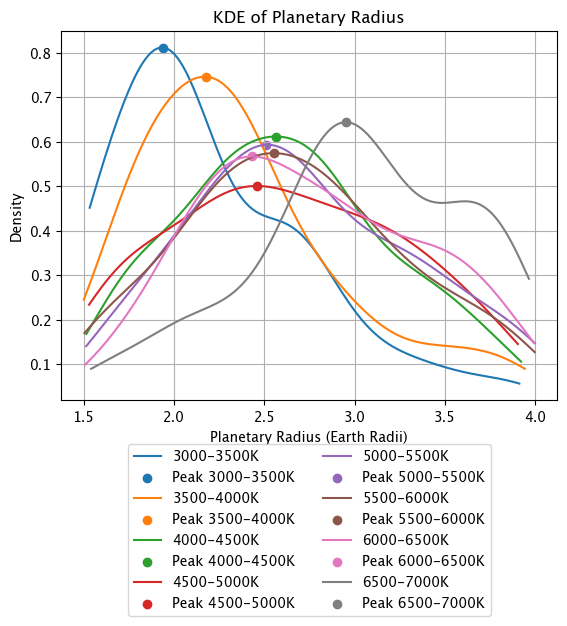

   Teff Min (K)  Teff Max (K)    Peak X    Peak Y  Average Temp
0          3000          3500  1.939636  0.811124        3250.0
1          3500          4000  2.175462  0.745717        3750.0
2          4000          4500  2.567005  0.611473        4250.0
3          4500          5000  2.460203  0.500467        4750.0
4          5000          5500  2.511999  0.592909        5250.0
5          5500          6000  2.556224  0.574176        5750.0
6          6000          6500  2.431906  0.566721        6250.0
7          6500          7000  2.953908  0.643634        6750.0


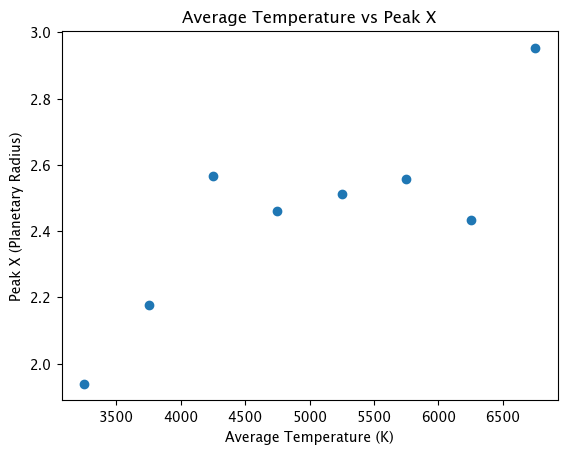

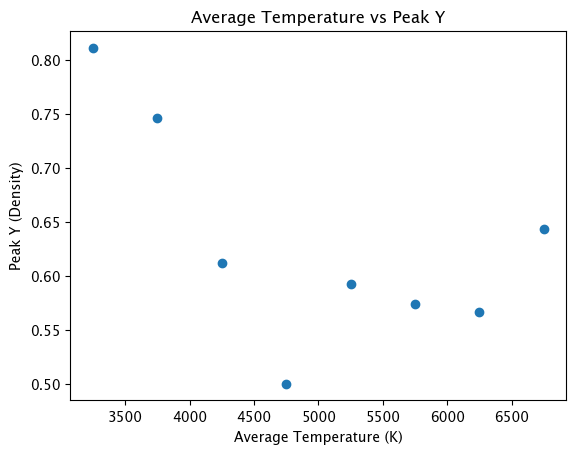

In [ ]:
teff_ranges = [(3000, 3500), (3500, 4000), (4000, 4500), (4500, 5000), (5000, 5500), (5500, 6000), (6000, 6500), (6500, 7000)]#, (7000,8000)]
rad_min = 1.5
rad_max =4
histogram_KDE('TOI_Mar2025.csv', 0, teff_ranges, rad_min, rad_max)

#do the giant planets increase at the same teff the mini-neptunes peak shifts?

In [ ]:
##FOR LOG
    # for teff_min, teff_max in teff_ranges:
    #     df_filtered = df[(df['st_teff'] < teff_max) & (df['st_teff'] > teff_min)]
    #     df_filtered = df_filtered[df_filtered['pl_rade'] > 0]

    #     log_radius = np.log10(df_filtered['pl_rade'])
    #     #print(log_radius)

    #     kde = sns.kdeplot(
    #         log_radius,
    #         alpha=1,
    #         label=f'{teff_min}-{teff_max}K',
    #         bw_adjust=1.0,
    #         cut=0
    #     )

    #     x, y = kde.get_lines()[-1].get_data()
    #     slopes = np.diff(y) / np.diff(x)
    #     max_slope = np.max(slopes)
    #     min_slope = np.min(slopes)

    #     mean = df_filtered['pl_rade'].mean()
    #     median = df_filtered['pl_rade'].median()
    #     mean_median_data.append({'Teff Range': f'{teff_min}-{teff_max}K', 'Mean': mean, 'Median': median})

    # xticks = [0, 0.3, 0.48, .6,0.7, 1.0,]
    # xtick_labels = [f"{10**tick:.1f}" for tick in xticks]
    # print(xtick_labels)
    # plt.xticks(ticks=xticks, labels=xtick_labels)

    # plt.xlabel('Planet Radius (Rearth)')
    # plt.ylabel('Density')
    # plt.title('KDE of Planet Radius (Log-transformed)')
    # plt.legend()
    # plt.grid(True)
    # plt.tight_layout()
    # plt.show()

Stellar Radius: 0.33 Rsun & Stellar Teff: 3250 K 
-> Minimum Detectable Planet Radius: 1.40 Rearth

Stellar Radius: 0.54 Rsun & Stellar Teff: 3750 K 
-> Minimum Detectable Planet Radius: 1.54 Rearth

Stellar Radius: 0.70 Rsun & Stellar Teff: 4250 K 
-> Minimum Detectable Planet Radius: 1.79 Rearth

Stellar Radius: 0.81 Rsun & Stellar Teff: 4750 K 
-> Minimum Detectable Planet Radius: 1.73 Rearth

Stellar Radius: 0.93 Rsun & Stellar Teff: 5250 K 
-> Minimum Detectable Planet Radius: 1.87 Rearth

Stellar Radius: 1.10 Rsun & Stellar Teff: 5750 K 
-> Minimum Detectable Planet Radius: 1.94 Rearth

Stellar Radius: 1.40 Rsun & Stellar Teff: 6250 K 
-> Minimum Detectable Planet Radius: 2.31 Rearth

Stellar Radius: 1.64 Rsun & Stellar Teff: 6750 K 
-> Minimum Detectable Planet Radius: 2.57 Rearth



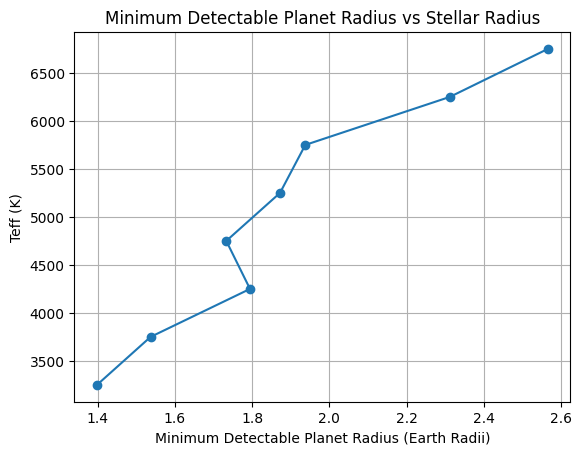

In [5]:
#Confused attempt at minimum detectable planet radii


rp_earth_values = []  # This will store the minimum detectable planet radii
rs_solar_values = (.3, .6, .7, .75, .85, 1.0, 1.3, 1.6) #table
rs_solar_values = (.3316638066666666, .5355935314285715, .7043664090909091, .8064671559241706, .9268146069908815, 1.0998090093394077, 1.4022025532608697, 1.6381640015384615) #average from TESS

teff_values = [3250, 3750, 4250, 4750, 5250, 5750, 6250, 6750] 
n_trans = 3.0
uncertainties = (1293.6957190937665, 599.3967867199419, 472.38156893948553, 336.10945076587586, 296.95755368160053, 225.90423476795883, 197.79928825555635, 178.4936251167114)

uncertainties = [u / 1000000 for u in uncertainties]
#print(uncertainties)
snr_target = 2

# Calculate minimum detectable planet radius for each stellar radius and uncertainty
for rs_solar, uncert in zip(rs_solar_values, uncertainties):
    rs_earth = rs_solar * 109.1  # Convert stellar radius to Earth radii
    rp_min = rs_earth * np.sqrt(snr_target * uncert / np.sqrt(n_trans))
    #snr50 = (rp_earth / rs_earth)**2 * np.sqrt(n_trans) / uncert 


    rp_earth_values.append(rp_min)

# Print the calculated minimum detectable planet radii for each stellar radius
for rs, rp, teff in zip(rs_solar_values, rp_earth_values, teff_values):
    print(f"Stellar Radius: {rs:.2f} Rsun & Stellar Teff: {teff} K \n-> Minimum Detectable Planet Radius: {rp:.2f} Rearth\n")
plt.plot(rp_earth_values, teff_values,marker='o')
plt.ylabel('Teff (K)')
plt.xlabel('Minimum Detectable Planet Radius (Earth Radii)')
plt.title('Minimum Detectable Planet Radius vs Stellar Radius')
plt.grid(True)
plt.show()